### Questions

#### Univariate
1. Where are the most jobs?  
   - Which countries have the highest posting counts?  
   - Which job categories dominate the dataset?  
2. When are most jobs posted?
#### Bivariate
3. How does the location of a job affect the salary?  
   - Where is the most lucrative salary?  
   - What are the most lucrative job categories?  

4. Is there any relation between posting date and salary?  
   - Do salaries vary by month, quarter, or season?  

5. How tight are salary ranges?  
   - What is the spread between minimum and maximum salaries?  

#### Multivariate
6. Are salaries more related to category or country?  
   - Which factor explains more variance in salaries?
   - 
#### Transformation
7. How does salary compression ratio (min/max) compare across industries?  
   - Do certain categories or regions show tighter or wider ranges?  

## Phase 4: Statistical EDA
### Part 1: Univariate Analysis

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df_filtered = pd.read_pickle("../data/cleaned_data.pkl")
df_filtered.head()

,id,title,company_name,category_label,category_tag,country,location_display,location_area,latitude,longitude,contract_type,contract_time,salary_min,salary_max,salary_mid,salary_is_predicted,created_dt,created_date,redirect_url,adref
0,5410474609,Mechanical Pipefitter,Dodd Group,Trade & Construction Jobs,trade-construction-jobs,United Kingdom,"King's Lynn, Norfolk",UK > Eastern England > Norfolk > King's Lynn,52.751999,0.395357,permanent,full_time,40518.74,40518.74,40518.74,1,2025-09-22 09:28:13+00:00,2025-09-22,https://www.adzuna.co.uk/jobs/details/54104746...,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTQxMDQ3NDYwOSIsI...
1,5381519011,International Trade Policy Editor [Startup Pol...,Applio Ventures,Graduate Jobs,graduate-jobs,United Kingdom,"London, UK",UK > London,NaN,NaN,permanent,full_time,64000.00,64000.00,64000.00,0,2025-09-03 21:20:59+00:00,2025-09-03,https://www.adzuna.co.uk/jobs/details/53815190...,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTM4MTUxOTAxMSIsI...
3,5403097985,Early Years BABY Room Leader,Jesters Childcare Essex,Teaching Jobs,teaching-jobs,United Kingdom,UK,UK,NaN,NaN,permanent,full_time,26707.00,29494.00,28100.50,0,2025-09-17 15:00:12+00:00,2025-09-17,https://www.adzuna.co.uk/jobs/details/54030979...,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTQwMzA5Nzk4NSIsI...
5,5404665589,Computer Systems Validation specialist,North Star Consulting UK,Scientific & QA Jobs,scientific-qa-jobs,United Kingdom,"Newcastle Upon Tyne, Tyne & Wear",UK > North East England > Tyne & Wear > Newcas...,NaN,NaN,permanent,full_time,65000.00,65000.00,65000.00,0,2025-09-18 10:29:32+00:00,2025-09-18,https://www.adzuna.co.uk/jobs/details/54046655...,eyJhbGciOiJIUzI1NiJ9.eyJzIjoiRWtwZjc5cWI4QkdZM...
6,5404864465,Full Stack Software Engineer,Marshall Wolfe Ltd,IT Jobs,it-jobs,United Kingdom,UK,UK,NaN,NaN,permanent,full_time,0.00,60000.00,30000.00,0,2025-09-18 14:32:46+00:00,2025-09-18,https://www.adzuna.co.uk/jobs/details/54048644...,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTQwNDg2NDQ2NSIsI...


In [3]:
# View relevant statistics for salary categories
print(df_filtered.nunique())
print(df_filtered[['salary_min', 'salary_max', 'salary_mid']].describe())

id                     1345
title                  1063
company_name            624
category_label           67
category_tag             30
country                   8
location_display        964
location_area           964
latitude                963
longitude               963
contract_type             2
contract_time             2
salary_min              795
salary_max              807
salary_mid              916
salary_is_predicted       2
created_dt             1096
created_date            211
redirect_url           1345
adref                  1346
dtype: int64
          salary_min     salary_max     salary_mid
count    1346.000000    1346.000000    1346.000000
mean    47527.442578   53017.268730   50272.355654
std     35305.787348   37694.082998   35959.681985
min         0.000000    1000.000000     601.000000
25%     26028.625000   30000.000000   28000.000000
50%     38425.450000   45020.925000   41791.315000
75%     59281.612500   65000.000000   61094.892500
max    384000.00000

Value Counts for each job description:

category_tag
healthcare-nursing-jobs          224
unknown                          221
teaching-jobs                    119
customer-services-jobs            92
logistics-warehouse-jobs          90
engineering-jobs                  77
trade-construction-jobs           59
it-jobs                           55
travel-jobs                       52
sales-jobs                        51
social-work-jobs                  50
hospitality-catering-jobs         40
manufacturing-jobs                34
accounting-finance-jobs           30
admin-jobs                        18
legal-jobs                        17
part-time-jobs                    16
retail-jobs                       16
maintenance-jobs                  14
pr-advertising-marketing-jobs     11
other-general-jobs                11
creative-design-jobs              10
domestic-help-cleaning-jobs       10
graduate-jobs                     10
consultancy-jobs                   5
hr-jobs               

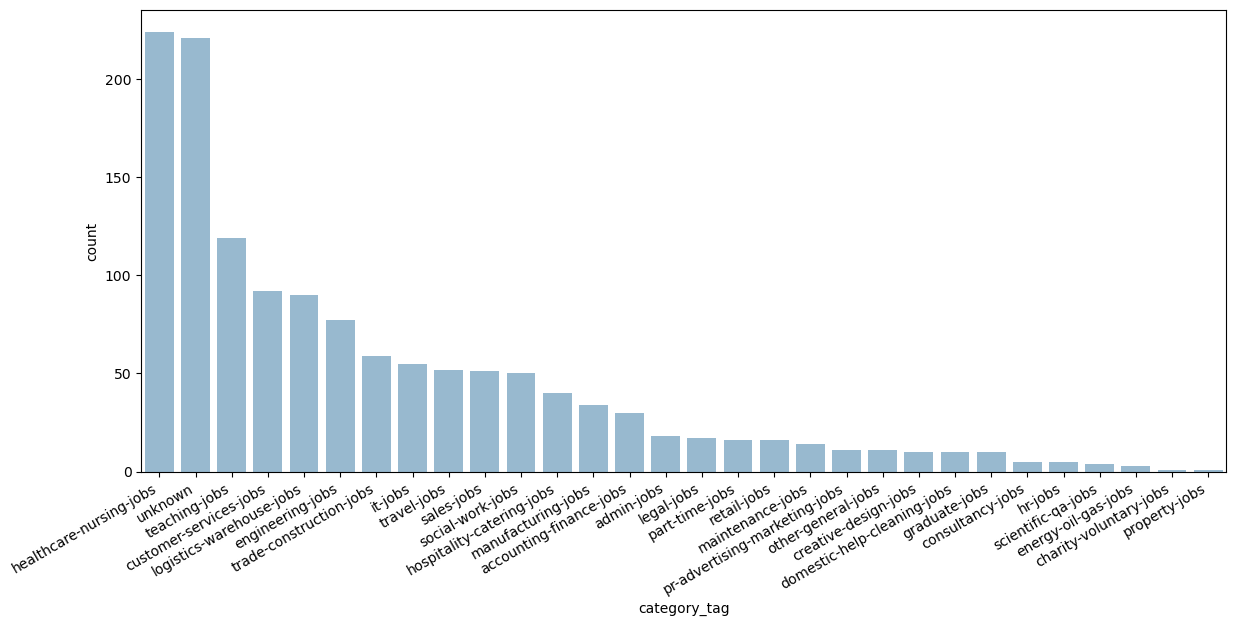

In [4]:
# Visualize the spread of job types
#sns.countplot(data = df_filtered, x = 'category_tag', alpha = 0.5)
#plt.xticks(rotation=30, ha='right')

# Set a wider figure size to spread out the bars
plt.figure(figsize=(14, 6))  

# sort categories by frequency
sorted_tags = df_filtered['category_tag'].value_counts().index

# Create the countplot with sorted categories
sns.countplot(data=df_filtered, x='category_tag', order=sorted_tags, alpha=0.5)

# Rotate x-axis labels for clarity
plt.xticks(rotation=30, ha='right')

print(f'Value Counts for each job description:\n\n{df_filtered['category_tag'].value_counts()}')

Healthcare accounts for the vast majority of job types with teaching, customer service, logistics, and engineering jobs accounting for another majority
It will be important to compare salary levels across these job types and make sure to account for low frequency jobs and their salaries in any consideration.

Value Counts for each job description:

country
USA               499
United Kingdom    480
Netherlands       129
France             92
Spain              88
Italy              43
Switzerland         8
Germany             7
Name: count, dtype: int64


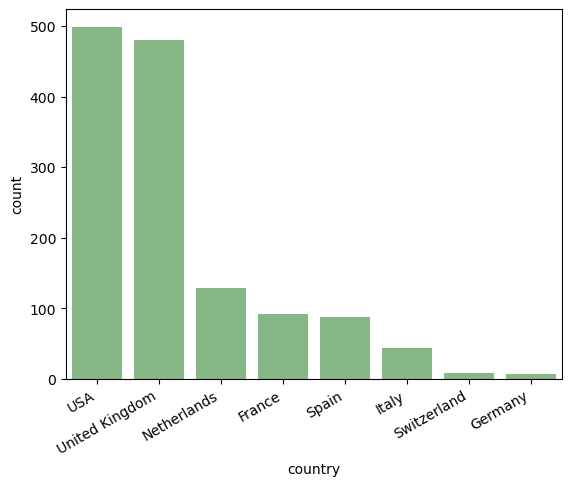

In [5]:
# Visualize the distribution of job locations

# sort countries by frequency
sorted_countries = df_filtered['country'].value_counts().index
ax = sns.countplot(data=df_filtered, x='country', color='Green', alpha=0.5, order = sorted_countries)

# Rotate x-axis labels
plt.xticks(rotation=30, ha='right')


print(f'Value Counts for each job description:\n\n{df_filtered['country'].value_counts()}')

Univariate analysis was duplicated from the job description analysis for countries. The United States and United Kingdom represent the location where the majority of jobs are found. France Netherlands and Spain are also countries to consider in locating trends in the data.


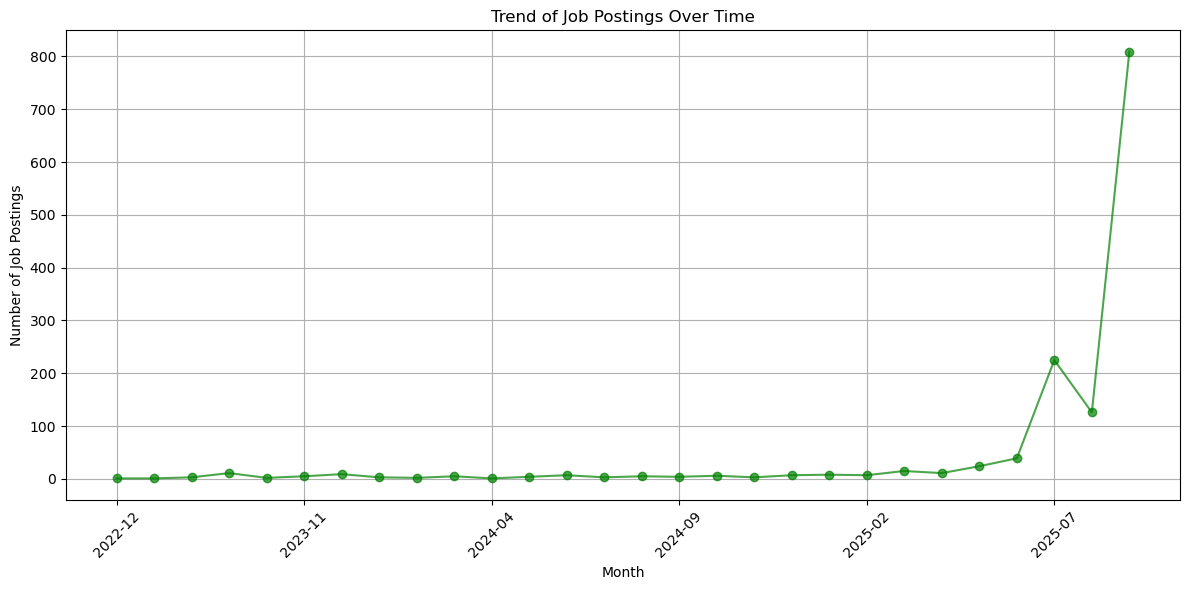

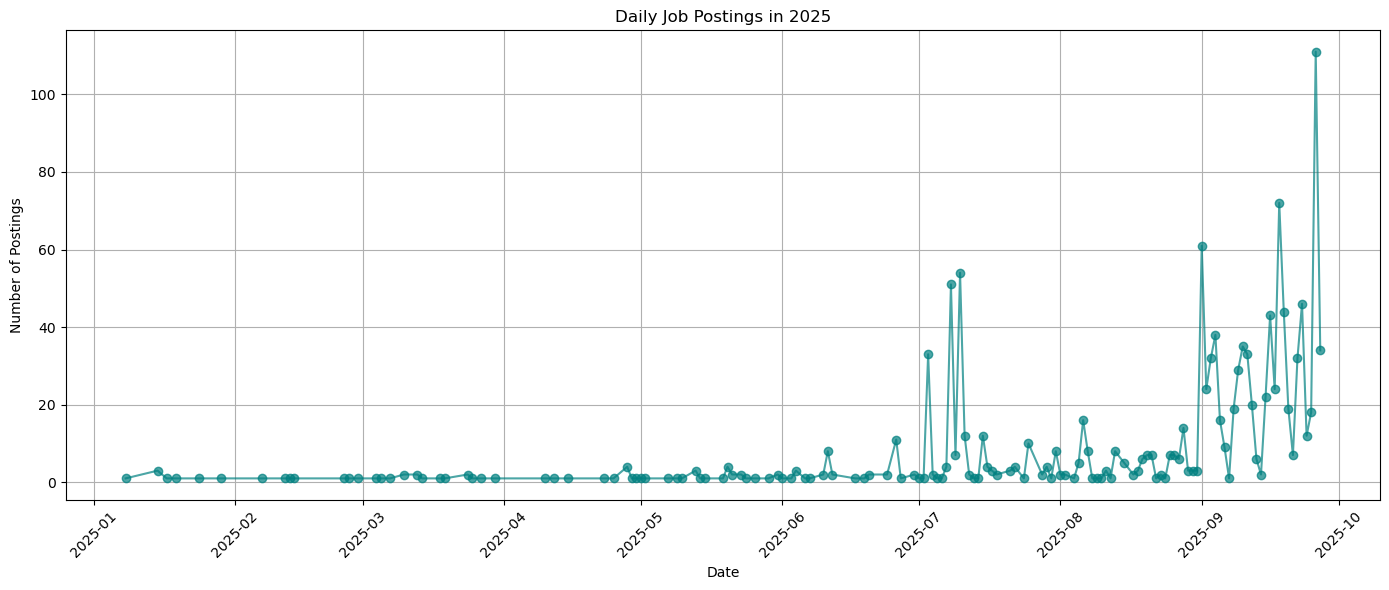

In [6]:
#Convertind created date to date time
df_filtered['created_date'] = pd.to_datetime(df_filtered['created_date'])

#Group by time period
df_filtered['created_month'] = df_filtered['created_date'].dt.to_period('M').astype(str)

# Count job postings per month
monthly_counts = df_filtered['created_month'].value_counts().sort_index()

# Plot the time series
plt.figure(figsize=(12, 6))
monthly_counts.plot(kind='line', marker='o', color='green', alpha=0.7)

# Label the axes and title
plt.xlabel("Month")
plt.ylabel("Number of Job Postings")
plt.title("Trend of Job Postings Over Time")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()



# Filter for only 2025 dates
df_2025 = df_filtered[df_filtered['created_date'].dt.year == 2025]

# Count postings by exact date
daily_counts_2025 = df_2025['created_date'].dt.date.value_counts().sort_index()

# Plot the daily trend for 2025
plt.figure(figsize=(14, 6))
daily_counts_2025.plot(kind='line', color='teal', marker='o', alpha=0.7)
plt.title("Daily Job Postings in 2025")
plt.xlabel("Date")
plt.ylabel("Number of Postings")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()



Initial observation of when jobs were posted was very skewed. This data was collected in 25, which made the original visualization very skewed, as very few jobs were found in the data from years before 2025. Even further before June of 2025, this trend continued. There was a heavy spike in job postings at the beginning of July 2025 and another large spike in the month of September, which saw the most consistently large number of jobs posted throughout the month. An exploration of how salaries posted during this time compare to salaries posted in other times.


After some outside research into this large jump, it can be attributed to a phenomenon called the September Surge, where employers begin a push in hiring with expected starts in the new year, as well as in an attempt to meet yearly objectives in filling positions (Royle). 

### Answers

#### Univariate
1. Where are the most jobs?
 
   - Which countries have the highest posting counts?
     
       The majority of job postings are in the US and the UK. Followed by the Netherlands, France, Spain, Italy, Switzerland, and Germany. This is most assuredly skewed by how the internet scraper finds jobs, and will be considered for the remainder of the analysis.
   - Which job categories dominate the dataset?
     
     There are significantly more healthcare jobs than any other named category. However, there are a large number of unknown jobs that did not recieve a proper category placement.

2. When are most jobs posted?


Most of the jobs on this list seem to have been posted from July 2025 to September 2025 which makes sense as even jobs that have been available for a long period will be temporarily reposted refreshing this post date.

### Part 2: Bivariate Analysis

Descending sort of average minimum salary by job:
                                       mean           std           var
category_tag                                                           
healthcare-nursing-jobs        81303.923080  46495.020812  2.161787e+09
accounting-finance-jobs        71100.483333  75967.892929  5.771121e+09
legal-jobs                     69754.387647  46301.875898  2.143864e+09
it-jobs                        64791.864000  32370.047556  1.047820e+09
travel-jobs                    61821.350192  15487.669114  2.398679e+08
scientific-qa-jobs             61565.325000  16135.025710  2.603391e+08
part-time-jobs                 60914.430625  42890.483824  1.839594e+09
property-jobs                  60000.000000           NaN           NaN
energy-oil-gas-jobs            53185.106667   2980.926359  8.885922e+06
sales-jobs                     52564.035098  26876.459066  7.223441e+08
trade-construction-jobs        50801.107119  25153.894424  6.327184e+08
engineering-jo

<Axes: xlabel='salary_min', ylabel='category_tag'>

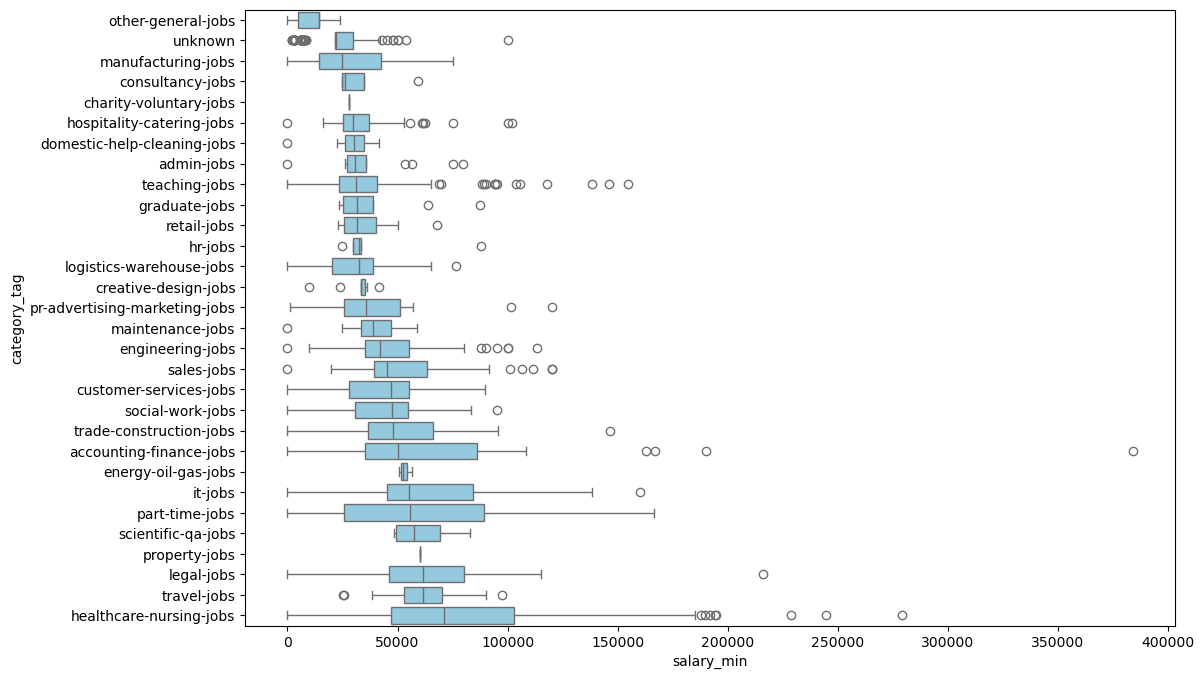

In [7]:
# Group salary by job type
df_job_type = df_filtered.groupby('category_tag')[['salary_min', 'salary_max', 'salary_mid']].agg(['mean', 'std', 'var'])

# Identify job types with the highest and lowest minimum salary and maximum salary
print("Descending sort of average minimum salary by job:")
print(df_job_type['salary_min'].sort_values(by = 'mean', ascending = False))

#Constructing box plot
plt.figure(figsize=(12, 8))  # Make the figure larger for readability

#original code 
#sns.boxplot(data = df_filtered, x = 'salary_min', y = 'category_tag')
order = df_filtered.groupby('category_tag')['salary_min'].median().sort_values().index

#Graph improved with copilot for clarity
sns.boxplot(data=df_filtered, x='salary_min', y='category_tag', order=order, color='skyblue')


Descending sort of average maximum salary by job:
                                       mean           std           var
category_tag                                                           
accounting-finance-jobs        87455.350000  93432.927392  8.729712e+09
healthcare-nursing-jobs        87134.088259  50423.392669  2.542519e+09
legal-jobs                     86272.034706  46104.067059  2.125585e+09
it-jobs                        71933.518545  29159.150510  8.502561e+08
scientific-qa-jobs             70815.325000  33634.967489  1.131311e+09
property-jobs                  70000.000000           NaN           NaN
part-time-jobs                 65769.180625  39410.555632  1.553192e+09
travel-jobs                    61951.504038  15305.312497  2.342526e+08
energy-oil-gas-jobs            61585.106667  17366.094378  3.015812e+08
trade-construction-jobs        58158.395254  21968.951870  4.826348e+08
sales-jobs                     55912.074314  28751.078037  8.266245e+08
engineering-jo

<Axes: xlabel='salary_max', ylabel='category_tag'>

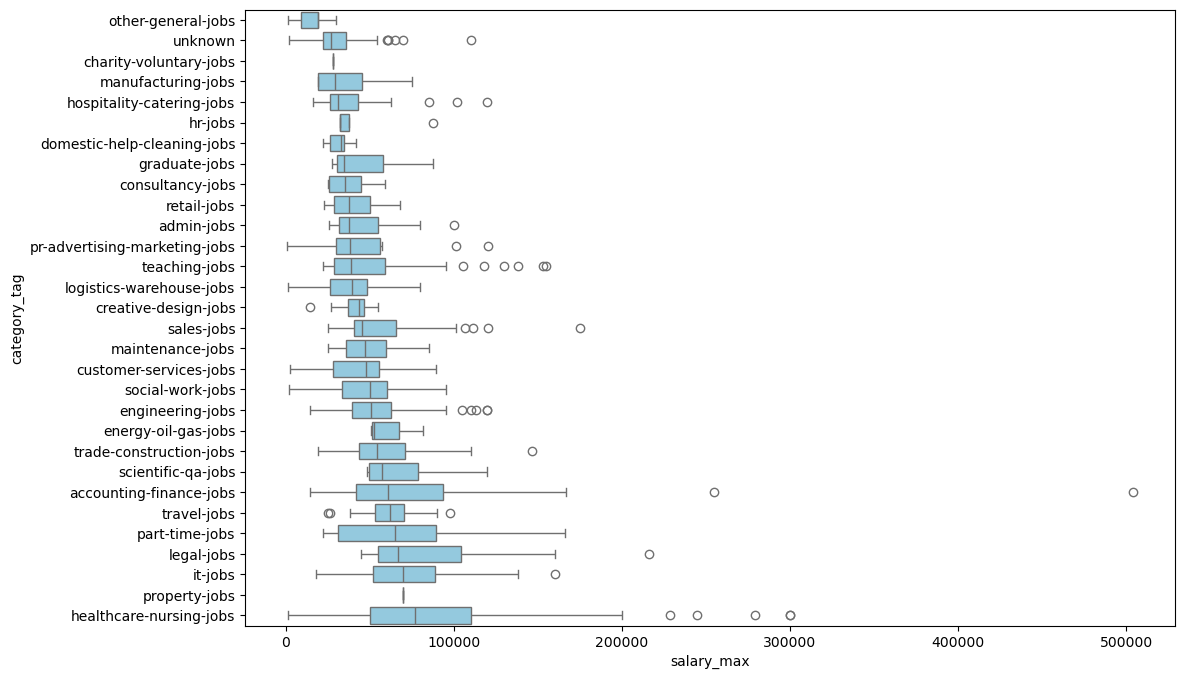

In [8]:
print("Descending sort of average maximum salary by job:")
print(df_job_type['salary_max'].sort_values(by = 'mean', ascending = False))

#sns.boxplot(data = df_filtered, x = 'salary_max', y = 'category_tag')

plt.figure(figsize=(12, 8))

# Sort categories by median salary_max 
order = df_filtered.groupby('category_tag')['salary_max'].median().sort_values().index

# Clean boxplot with single color 
sns.boxplot(
    data=df_filtered,
    x='salary_max',
    y='category_tag',
    order=order,
    color='skyblue' 
)


Comparing the average minimum and maximum salaries by job type we see some expected results. Healthcare jobs have the highest minimum salaries and second highest maximum salaries. It being a vital and skillful industry it is expected to see high pay.
An interesting point to note is the difference in average min and max salary for legal jobs, 86272 v. 69754. The box plots indicate a high range of salaries in legal jobs, and in the min boxplot there are values that reach 0. This result can indicate jobs being done pro-bono or as a result of missing values in the data set.
Sorting the jobs by their average salary gives us a way to view the value that is placed on work being done, as well as gives us indicators on intertest in different industries.

Descending sort of average minimum salary by country:
                        mean           std           var
country                                                 
USA             72953.445812  37795.429226  1.428494e+09
Germany         70428.571429  41287.032439  1.704619e+09
Switzerland     45875.000000  21675.776473  4.698393e+08
United Kingdom  36570.604688  19230.741123  3.698214e+08
Netherlands     33779.527132  19102.163210  3.648926e+08
France          28919.565217  39327.791921  1.546675e+09
Italy           17106.976744   9003.528286  8.106352e+07
Spain           15914.988636  13453.433335  1.809949e+08


<Axes: xlabel='salary_min', ylabel='country'>

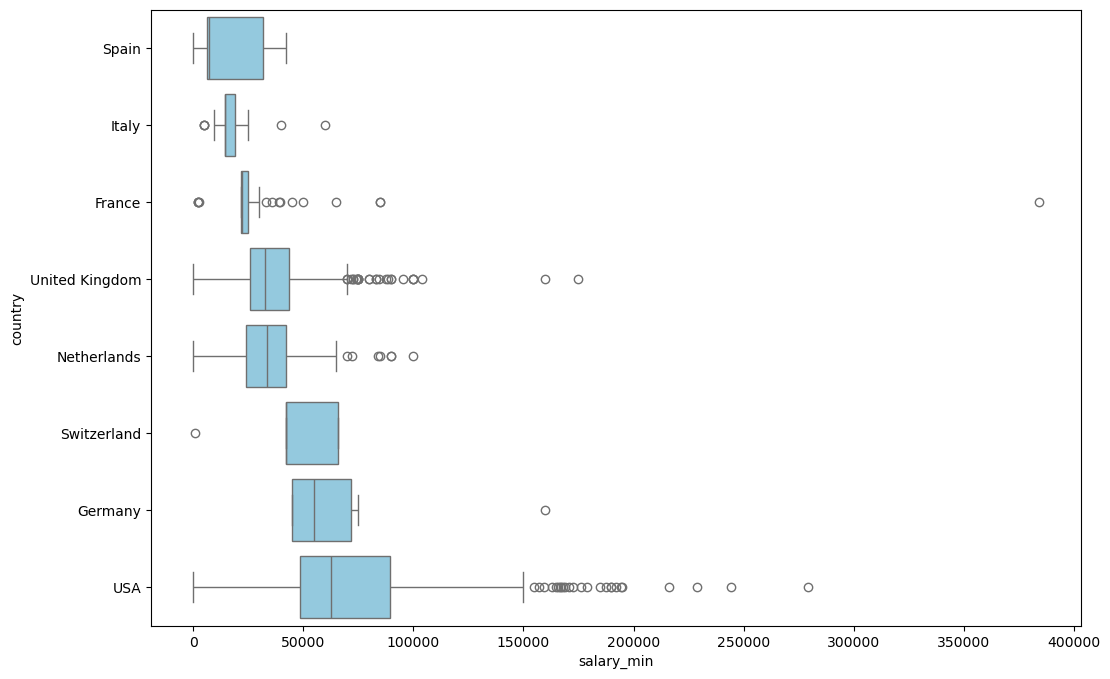

In [9]:
# Repeat for location
df_location = df_filtered.groupby('country')[['salary_min', 'salary_max', 'salary_mid']].agg(['mean', 'std', 'var'])

# Identify job types with the highest and lowest minimum salary and maximum salary
print("Descending sort of average minimum salary by country:")
print(df_location['salary_min'].sort_values(by = 'mean', ascending = False))

#sns.boxplot(data = df_filtered, x = 'salary_min', y = 'country')

plt.figure(figsize=(12, 8))

# Sort countries by median salary_min
order = df_filtered.groupby('country')['salary_min'].median().sort_values().index

# Clean boxplot
sns.boxplot(
    data=df_filtered,
    x='salary_min',
    y='country',
    order=order,
    color='skyblue')

Descending sort of average maximum salary by country:
                        mean           std           var
country                                                 
USA             72953.445812  37795.429226  1.428494e+09
Germany         70428.571429  41287.032439  1.704619e+09
Switzerland     45875.000000  21675.776473  4.698393e+08
United Kingdom  36570.604688  19230.741123  3.698214e+08
Netherlands     33779.527132  19102.163210  3.648926e+08
France          28919.565217  39327.791921  1.546675e+09
Italy           17106.976744   9003.528286  8.106352e+07
Spain           15914.988636  13453.433335  1.809949e+08


<Axes: xlabel='salary_max', ylabel='country'>

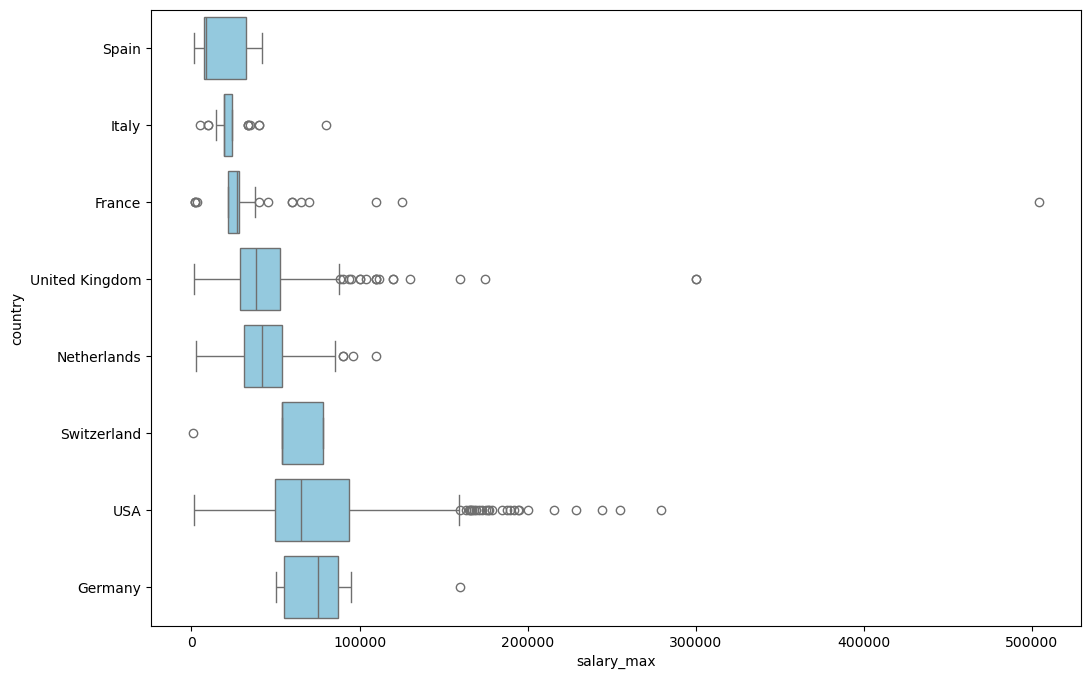

In [10]:
# Identify job types with the highest and lowest minimum salary and maximum salary
print("Descending sort of average maximum salary by country:")
print(df_location['salary_min'].sort_values(by = 'mean', ascending = False))

#sns.boxplot(data = df_filtered, x = 'salary_max', y = 'country')

plt.figure(figsize=(12, 8))

# Sort countries by median salary_max
order = df_filtered.groupby('country')['salary_max'].median().sort_values().index

# Clean boxplot with single color
sns.boxplot(
    data=df_filtered,
    x='salary_max',
    y='country',
    order=order,
    color='skyblue')

The categorization was repeated with average minimum and maximum average salaries but now to compare over locations. The countries listed represent locations of interest where the job market can be best studied. The USA and UK contain the most job listings, however the job listings in the USA offer significantly higher average salarlies. Spain's job listings have low variability with salary, but are also the lowest on average compared to every other country. 
Germany job listing salaries are the closest to the USA's (72953 vs. 70428), with the next closest being almost 30,000 behind. Germany had low variabilty with high salary, but also only had 7 job listings. This is fact that we chose to expand on further to see what industries Germany is offering jobs in and why there may be a reason for the high average salaries. 

In [11]:
jobs_by_country = pd.crosstab(index = df_filtered['category_tag'], columns = df_filtered['country'])

german_jobs = jobs_by_country[(jobs_by_country['Germany'] != 0)]
german_jobs

country,France,Germany,Italy,Netherlands,Spain,Switzerland,USA,United Kingdom
category_tag,,,,,,,,
healthcare-nursing-jobs,2,2,3,0,0,1,178,38
it-jobs,0,5,1,7,0,1,12,29


Germany's job listings consist in the healthcare and IT industries, two of the highest ranking average salary industries shown earlier. With this being the case it is no surprise that the German market relate to the US's. However, with only 7 total job listings it cannot be considered significant enough to say that the German job market is performing at the same level as the US market.

Salary statistics comparing September vs. other months:

                salary_min                                             \
                      mean   median           std           var count   
is_september                                                            
False         48953.805977  37320.0  37953.217445  1.440447e+09   522   
True          46623.848289  39000.0  33513.079523  1.123126e+09   824   

                salary_max                                               \
                      mean     median           std           var count   
is_september                                                              
False         53515.014789  45020.925  38928.014373  1.515390e+09   522   
True          52701.949017  45050.730  36911.529886  1.362461e+09   824   

                salary_mid                                               
                      mean     median           std           var count  
is_september                                         

<Axes: xlabel='is_september', ylabel='salary_mid'>

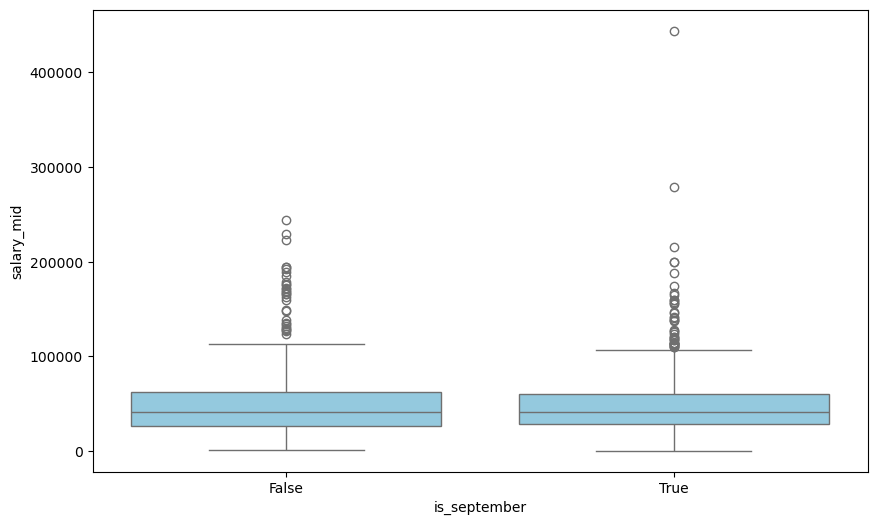

In [12]:
# Ensure created_date is datetime
df_filtered['created_date'] = pd.to_datetime(df_filtered['created_date'], errors='coerce')

# Flag september postings
df_filtered['is_september'] = df_filtered['created_date'].dt.month == 9

# Salary: September vs other months
salary_stats = df_filtered.groupby('is_september')[['salary_min', 'salary_max', 'salary_mid']].agg(
    ['mean','median', 'std', 'var', 'count']
)
print("Salary statistics comparing September vs. other months:\n")
print(salary_stats)

# visualize
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_filtered,
    x='is_september',
    y='salary_mid',
    color='skyblue')

It appears there is no real difference in salaries posted in september vs other months. The Box-Whisker plot reveals nearly identicle quartiles and median salaries. However, it does look like there are a few more high end outliers in September which may indicate a higher amount of large compensation jobs posted in September. 

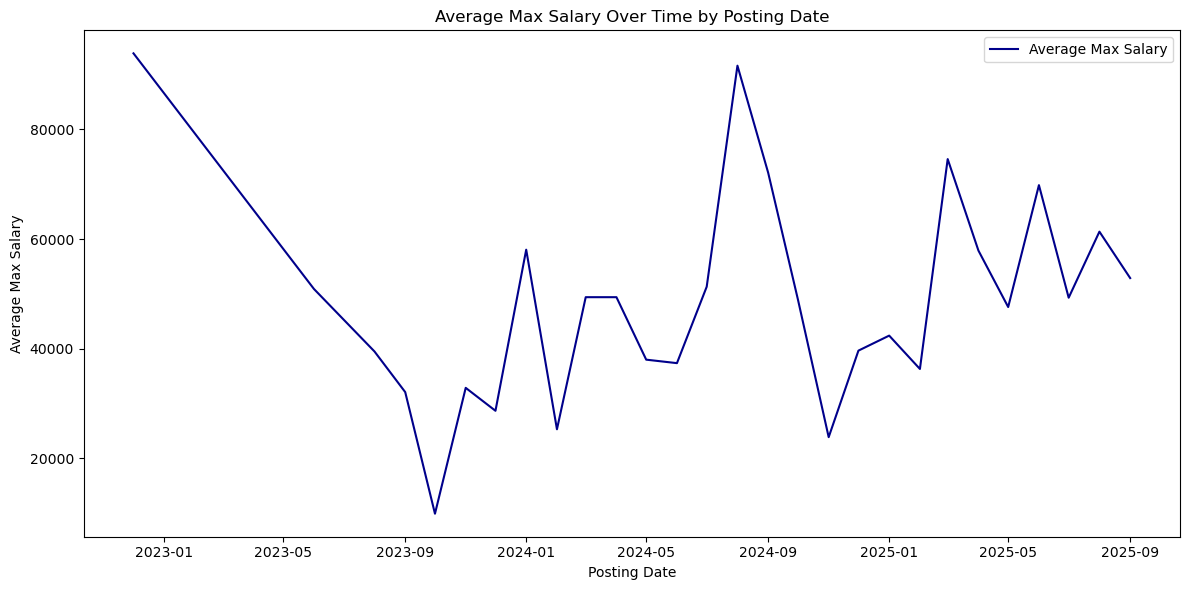

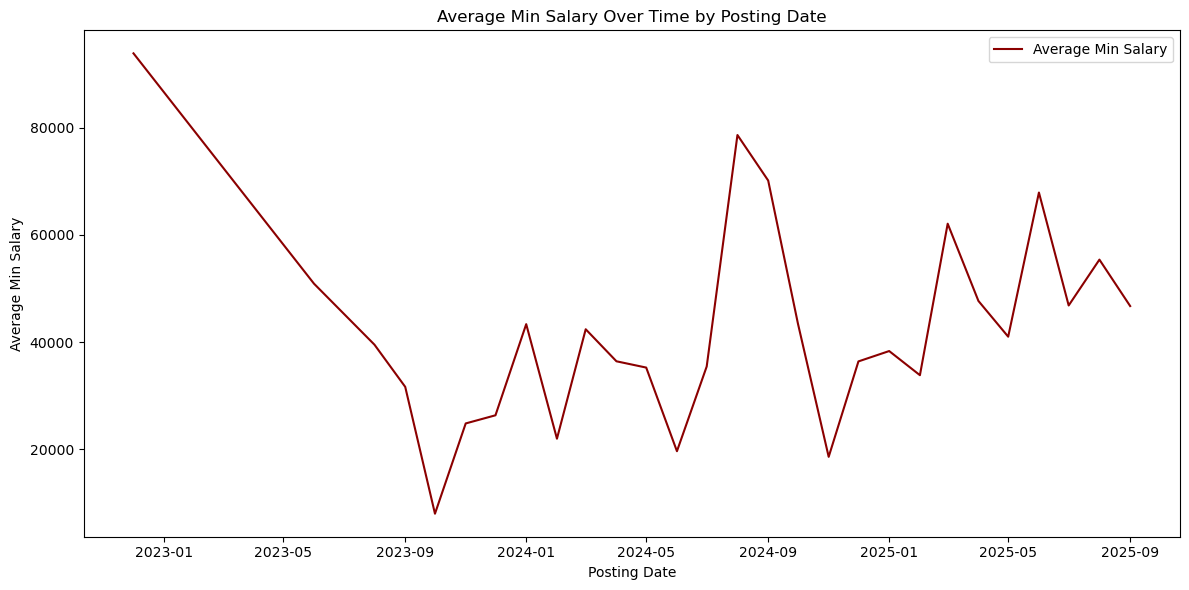

                   avg_min_salary  avg_max_salary  count
end_of_month_post                                       
First 15 Days        47370.048946    52398.414760    626
Last 15 Days         47664.287597    53555.327875    720


In [21]:
# Extract useful time features
df_filtered['year'] = df_filtered['created_date'].dt.year
df_filtered['month'] = df_filtered['created_date'].dt.month

# Group by month-year and calculate average salaries
salary_by_date = (
    df_filtered.groupby([df_filtered['year'], df_filtered['month']])
               .agg(avg_min_salary=('salary_min', 'mean'),
                    avg_max_salary=('salary_max', 'mean'))
               .reset_index()
)

# Create a combined datetime column for plotting
salary_by_date['period'] = pd.to_datetime(
    salary_by_date[['year', 'month']].assign(day=1)
)

# --- Plot only Average Max Salary ---
plt.figure(figsize=(12, 6))
sns.lineplot(data=salary_by_date, x='period', y='avg_max_salary', color='darkblue', label='Average Max Salary')
plt.title('Average Max Salary Over Time by Posting Date')
plt.xlabel('Posting Date')
plt.ylabel('Average Max Salary')
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot only Average Min Salary ---
plt.figure(figsize=(12, 6))
sns.lineplot(data=salary_by_date, x='period', y='avg_min_salary', color='darkred', label='Average Min Salary')
plt.title('Average Min Salary Over Time by Posting Date')
plt.xlabel('Posting Date')
plt.ylabel('Average Min Salary')
plt.legend()
plt.tight_layout()
plt.show()


# Flag jobs posted in the last 15 days of the month
df_filtered['day'] = df_filtered['created_date'].dt.day
df_filtered['end_of_month_post'] = df_filtered['day'] >= 15

# Compare average salaries for early vs. late month postings
salary_comparison = (
    df_filtered.groupby('end_of_month_post')
               .agg(avg_min_salary=('salary_min', 'mean'),
                    avg_max_salary=('salary_max', 'mean'),
                    count=('salary_max', 'size'))
               .rename(index={True: 'Last 15 Days', False: 'First 15 Days'})
)

print(salary_comparison)



There is no clear linear relationship between when a job is posted and how much it pays. However, there are noticeable spikes in both minimum and maximum salaries, which may be driven by external factors or cyclical and seasonal hiring patterns among employers. A comparison of job postings from the first 15 days versus the last 15 days of each month reveals a modest but consistent difference in pay. Jobs posted in the last half of the month have a slightly higher average minimum salary of 47,664 compared to 47,370 in the first half, and a higher average maximum salary of 53,555 compared to 52,398. This difference, while small, could reflect a stronger urgency to fill roles quickly or align with companies’ end-of-month hiring targets and budget cycles. This is reflected for some months in the graph as well.

Salary Spread Summary:
 count      1346.000000
mean       5489.826152
std       12739.313664
min           0.000000
25%           0.000000
50%           0.000000
75%        6000.000000
max      200000.000000
Name: salary_spread, dtype: float64

Relative Spread Summary:
 count    1346.000000
mean        0.114526
std         0.190976
min         0.000000
25%         0.000000
50%         0.000000
75%         0.181818
max         1.000000
Name: relative_spread, dtype: float64


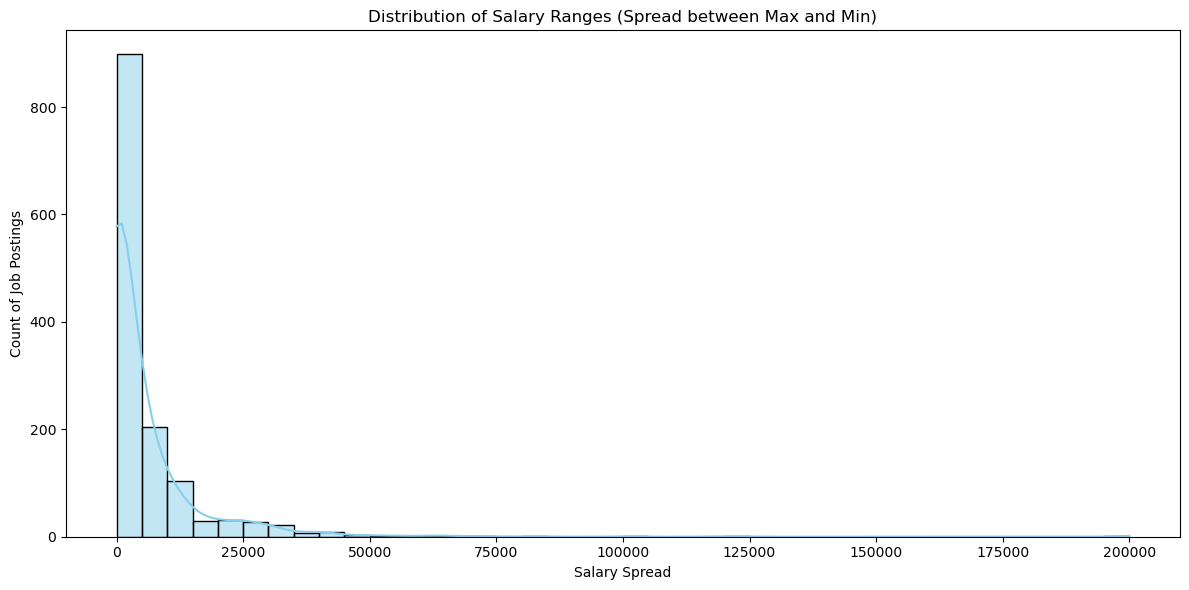

In [22]:
# Calculate the spread between min and max salaries for each posting
df_filtered['salary_spread'] = df_filtered['salary_max'] - df_filtered['salary_min']

# Summary statistics of the spread
spread_summary = df_filtered['salary_spread'].describe()
print("Salary Spread Summary:\n", spread_summary)

# Average tightness of ranges (relative spread)
df_filtered['relative_spread'] = df_filtered['salary_spread'] / df_filtered['salary_max']
relative_summary = df_filtered['relative_spread'].describe()
print("\nRelative Spread Summary:\n", relative_summary)

# Optional: visualize distribution of spreads
plt.figure(figsize=(12, 6))
sns.histplot(df_filtered['salary_spread'], bins=40, color='skyblue', kde=True)
plt.title('Distribution of Salary Ranges (Spread between Max and Min)')
plt.xlabel('Salary Spread')
plt.ylabel('Count of Job Postings')
plt.tight_layout()
plt.show()

The summary shows that salary ranges are generally quite tight, with many postings listing identical minimum and maximum salaries. The median spread is 0, meaning at least half of the jobs report no range at all. When ranges do exist, the upper quartile spread is around 6,000, and the mean spread is about 5,490, though a few extreme cases stretch up to 200,000.


### Questions

#### Bivariate
3. How does the location of a job affect the salary?  
   - Where is the most lucrative salary?
 
    USA: Offers the highest average salaries overall, with a wide range of postings across industries. Contains the third highest single salary.

   
    Germany: Average salaries are close to the USA  (≈72,953 vs. 70,428), but based on only 7 postings, so not statistically significant.

   
    UK: A Large number of postings, but average salaries are slightly lower than in the US. It also contains the second-largest single salary.
   
    Spain: Lowest average salaries with very low variability, indicating limited salary diversity across postings.

    France: Has the highest single salary, but it is a significant outlier.

      
   - What are the most lucrative job categories?
      
        Legal:
        
        a. Wide salary ranges with notable anomalies.
        b. Boxplots reveal extreme variability, including entries with minimum salary = 0. Indicating pro-bono work
        
        Healthcare:
        
        a.Highest minimum salaries across all categories.
        b.Second-highest maximum salaries.
        c.Reflects the critical and specialized nature of healthcare work.
        
        IT / Technology:
        
        a. Consistently high average salaries.
        b. Strong contributor to Germany’s elevated salary averages.
        c. Aligns with global demand for technical skills.
        
        Other Observations:
        
        a. Sorting categories by average salary highlights how markets value different industries.
        b. Industries with narrow ranges (e.g., Spain’s postings) suggest lower variability and less diversity in compensation.

    

5. Is there any relation between posting date and salary?

There is no strong linear relationship between posting date and salary, though occasional spikes in both minimum and maximum salaries suggest external influences or cyclical hiring patterns. Jobs posted toward the end of the month show slightly higher pay, which may reflect urgency to meet staffing or budget objectives

   - Do salaries vary by month, quarter, or season?
     
Salaries do vary by month, quarter, or season, with noticeable peaks and troughs that align with hiring cycles, budget resets, or industry-specific demand. These fluctuations indicate that compensation levels are influenced more by broader economic and organizational rhythms than by the exact posting date.

6. How tight are salary ranges?

    Salary ranges are generally very tight, with most postings showing no difference between minimum and maximum pay.

   - What is the spread between minimum and maximum salaries?
     
     When a spread exists, it averages about 5,490 but can extend up to 200,000 in rare cases.

### Part 3: Multivariate Analysis

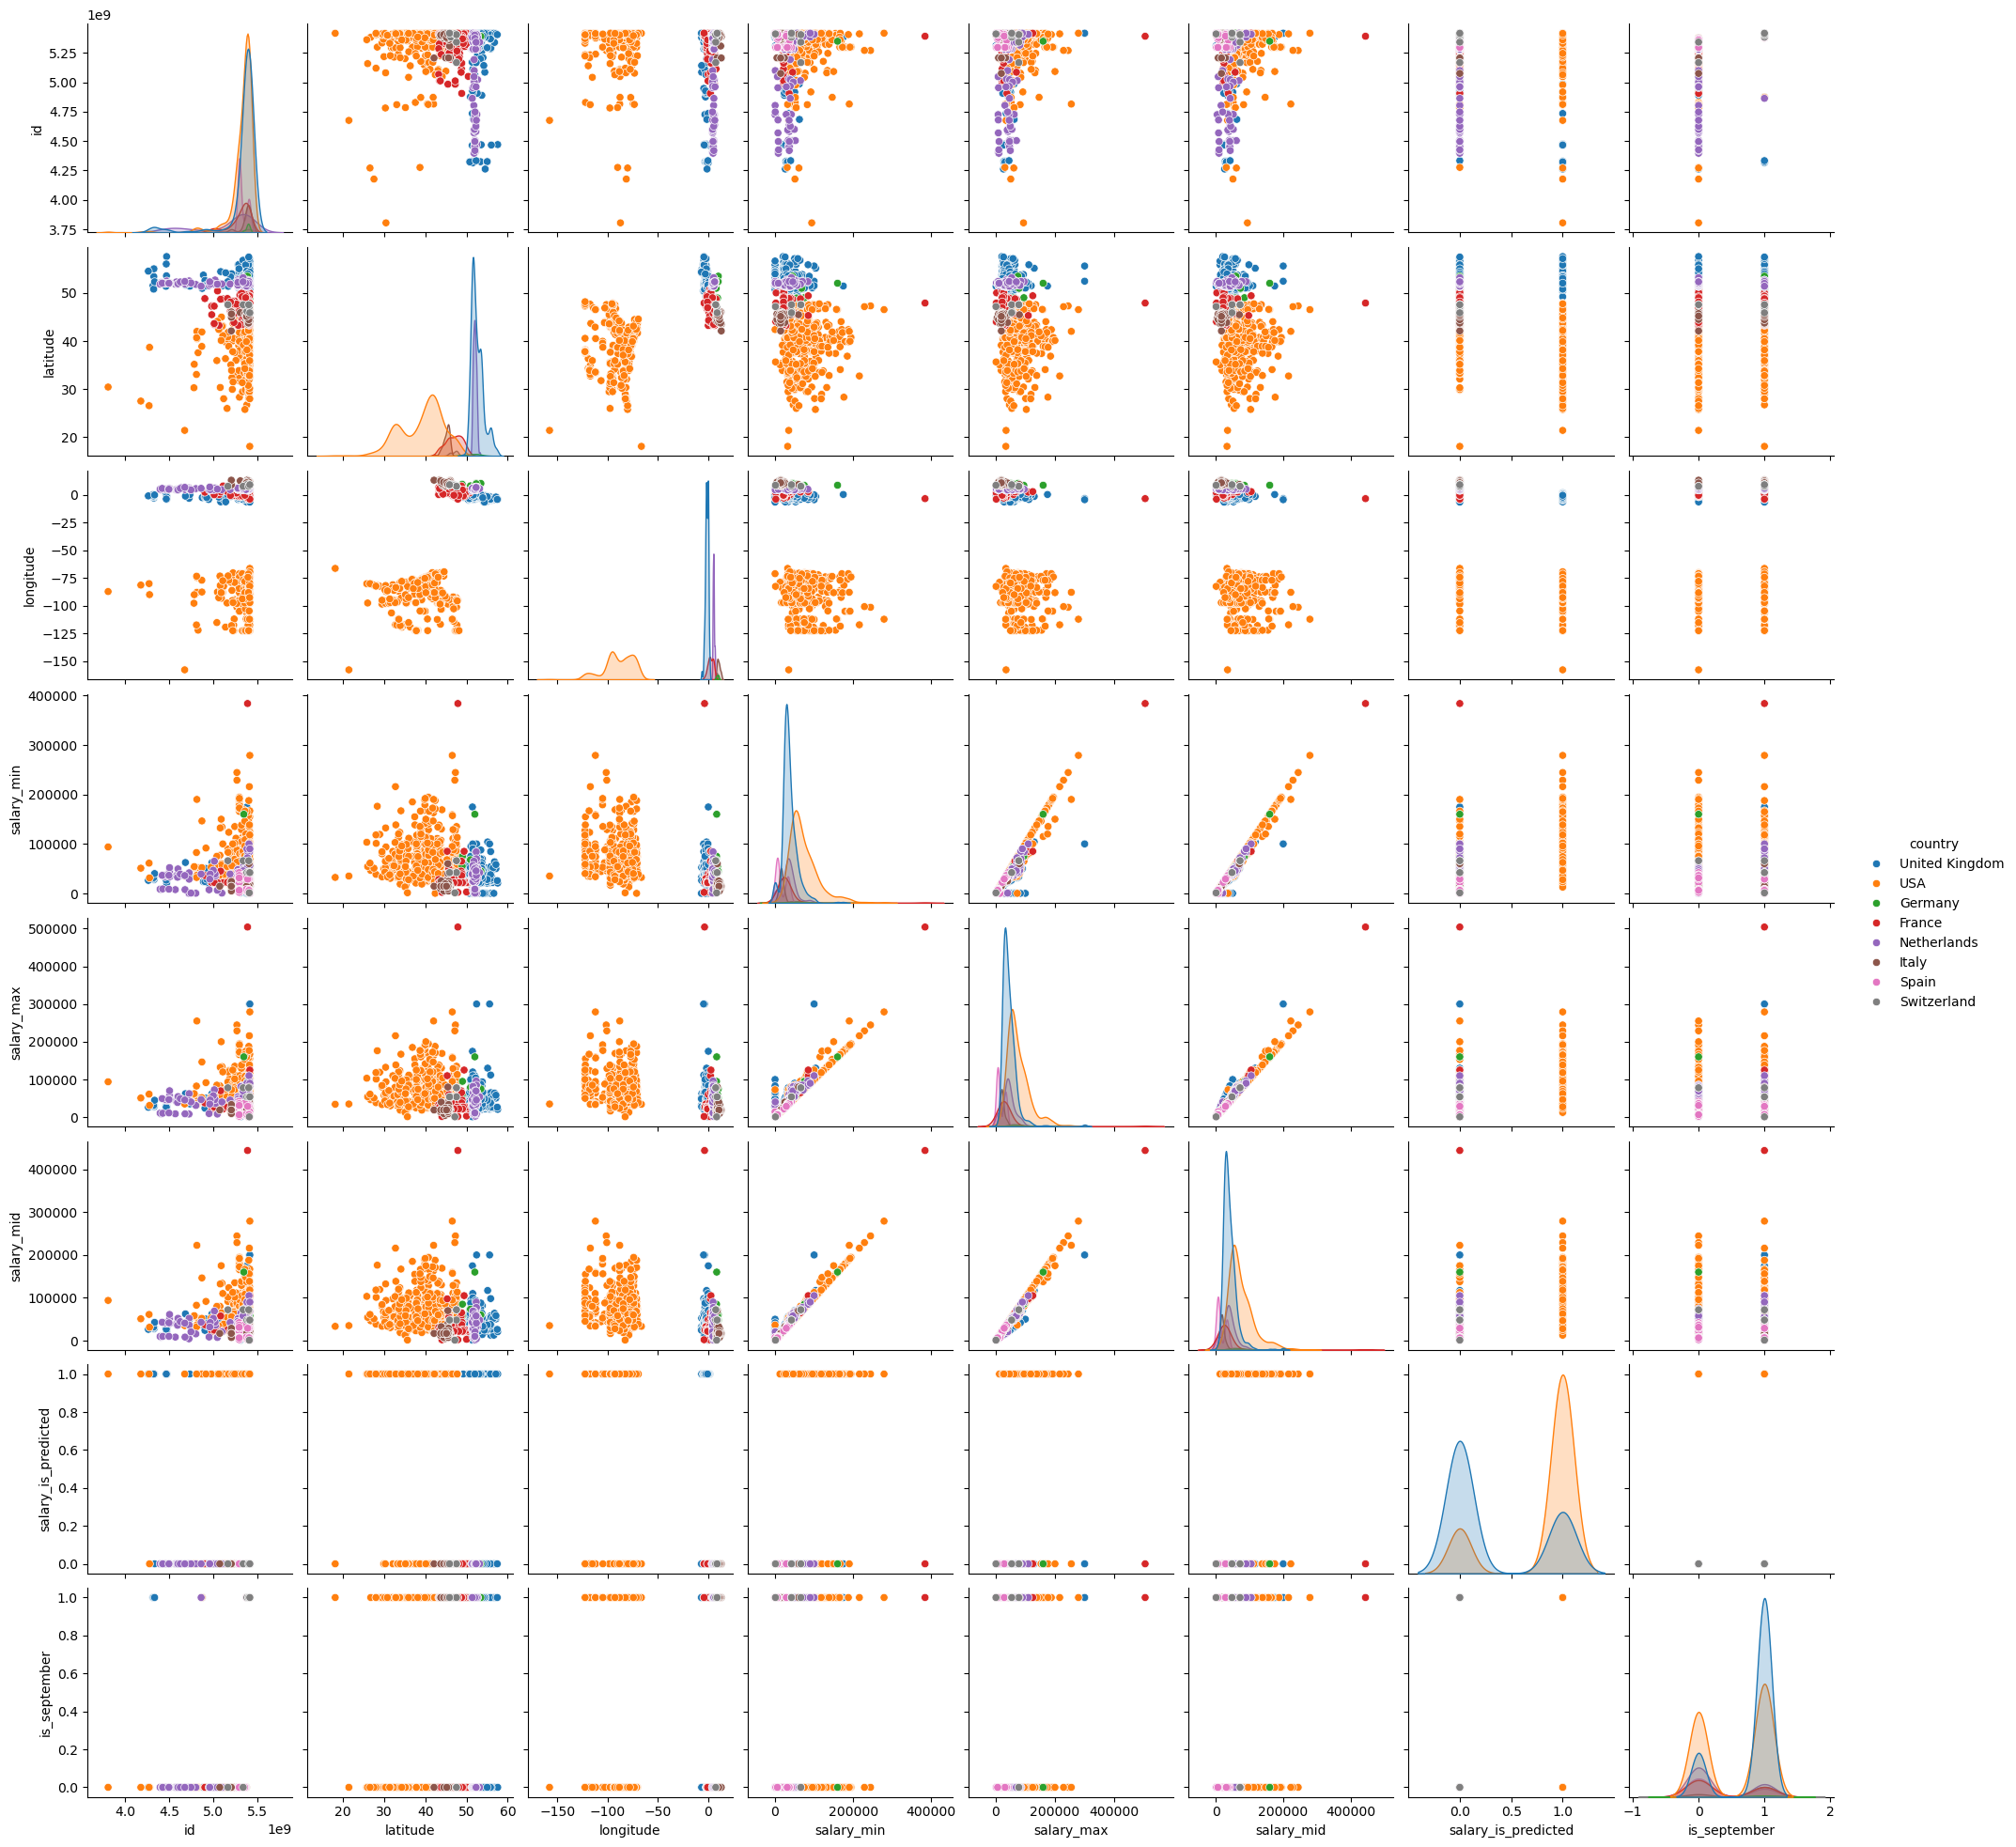

In [13]:
sns.pairplot(df_filtered, hue = 'country')

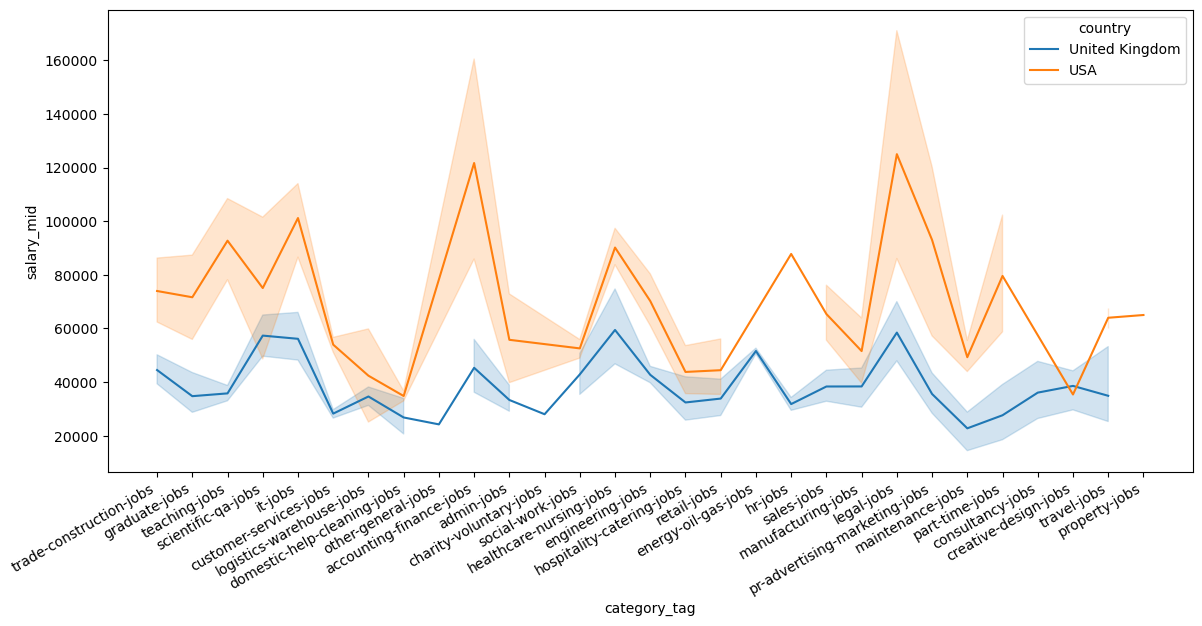

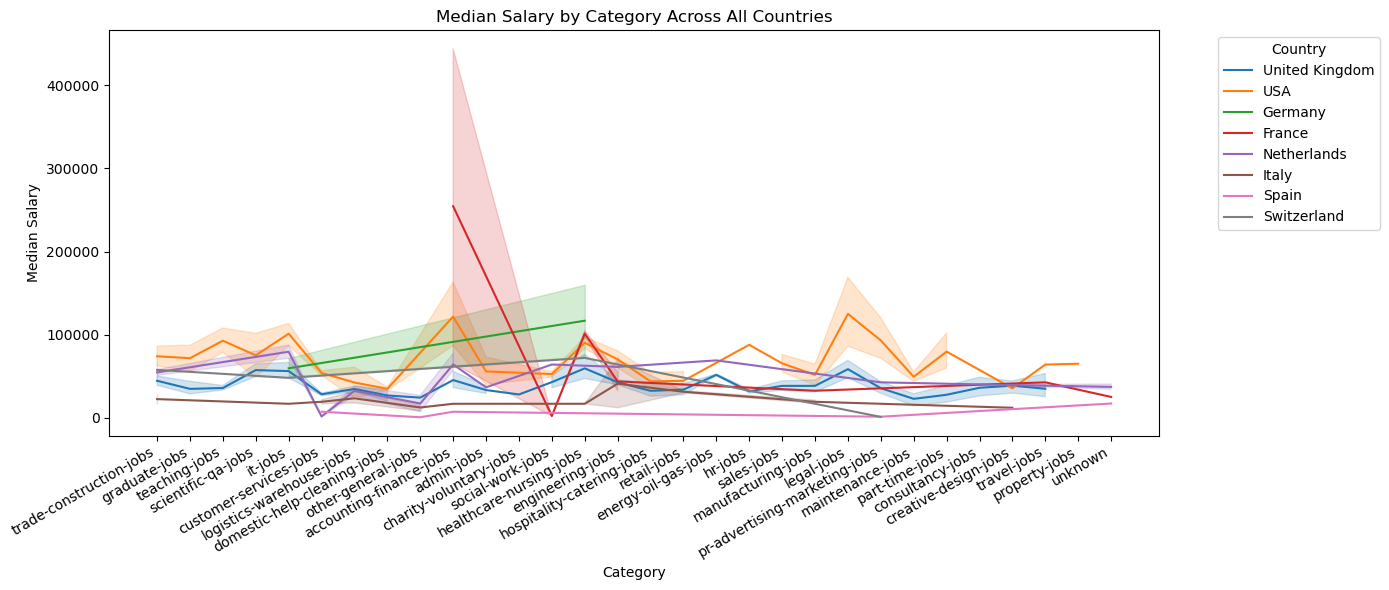

Average variance explained by category: 813247070.8362437
Average variance explained by country: 847542337.9424216


In [25]:
us_uk = df_filtered[(df_filtered['country'] == 'United Kingdom') | (df_filtered['country'] == 'USA')]
us_uk

plt.figure(figsize=(14, 6)) 
sns.lineplot(data = us_uk, x = 'category_tag', y = 'salary_mid', hue = 'country')
plt.xticks(rotation=30, ha='right')

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_filtered, x='category_tag', y='salary_mid', hue='country')

plt.xticks(rotation=30, ha='right')
plt.title('Median Salary by Category Across All Countries')
plt.xlabel('Category')
plt.ylabel('Median Salary')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')  # move legend outside for clarity
plt.tight_layout()
plt.show()

# Variance of salaries by category
category_var = df_filtered.groupby('category_tag')['salary_mid'].var().mean()

# Variance of salaries by country
country_var = df_filtered.groupby('country')['salary_mid'].var().mean()

print("Average variance explained by category:", category_var)
print("Average variance explained by country:", country_var)



To compare the two countries with the highest total job listings, The UK and USA, we used a linplot to chart the average mid salary across every job type. The line chart confirms the observation in bivariate analysis that the UK offers significantly lower average salaries. However, looking at the linechart, it indicates that both markets place similar value on each industry. The lines follow a very similar trend, peaking and valleying at the same job types. This indicates that the two markets operated in the same way with the difference lying in the salary amounts that are offered. Because of this, it can be said that job opportunities in the United States are much more lucrative compared to the UK.

The graph of all countries shows a broadly similar trend, with many following the same pattern of peaks and valleys. Some countries, however, display a weaker correlation with category, as their lines remain relatively flat across the entire plot. This is particularly evident for Spain and Italy, though even in these cases small peaks are still visible.

#### Answers
6. Are salaries more related to category or country?

Salaries are related to both category and country, but the line plots suggest that category drives the overall shape of salary trends, with industries peaking and dipping in similar places across nations. Country, on the other hand, shifts the absolute level of pay, as seen in the consistent gap between the UK and USA.

   - Which factor explains more variance in salaries?

        Numerically, the variance analysis showed that country explains slightly more variance in salaries than category, though the difference is small. This indicates that while job type determines the relative structure of salaries, location exerts a marginally stronger influence on the actual amounts offered


### Part 4: Transformation


Average compression ratio by industry:
 category_tag
other-general-jobs               0.685111
logistics-warehouse-jobs         0.785617
legal-jobs                       0.789517
maintenance-jobs                 0.790096
accounting-finance-jobs          0.791859
creative-design-jobs             0.793355
teaching-jobs                    0.825822
manufacturing-jobs               0.840255
admin-jobs                       0.845771
trade-construction-jobs          0.848130
property-jobs                    0.857143
graduate-jobs                    0.869120
part-time-jobs                   0.878177
domestic-help-cleaning-jobs      0.884820
it-jobs                          0.888330
retail-jobs                      0.890752
unknown                          0.891615
engineering-jobs                 0.892751
consultancy-jobs                 0.896435
energy-oil-gas-jobs              0.897059
pr-advertising-marketing-jobs    0.902160
customer-services-jobs           0.905997
hr-jobs                

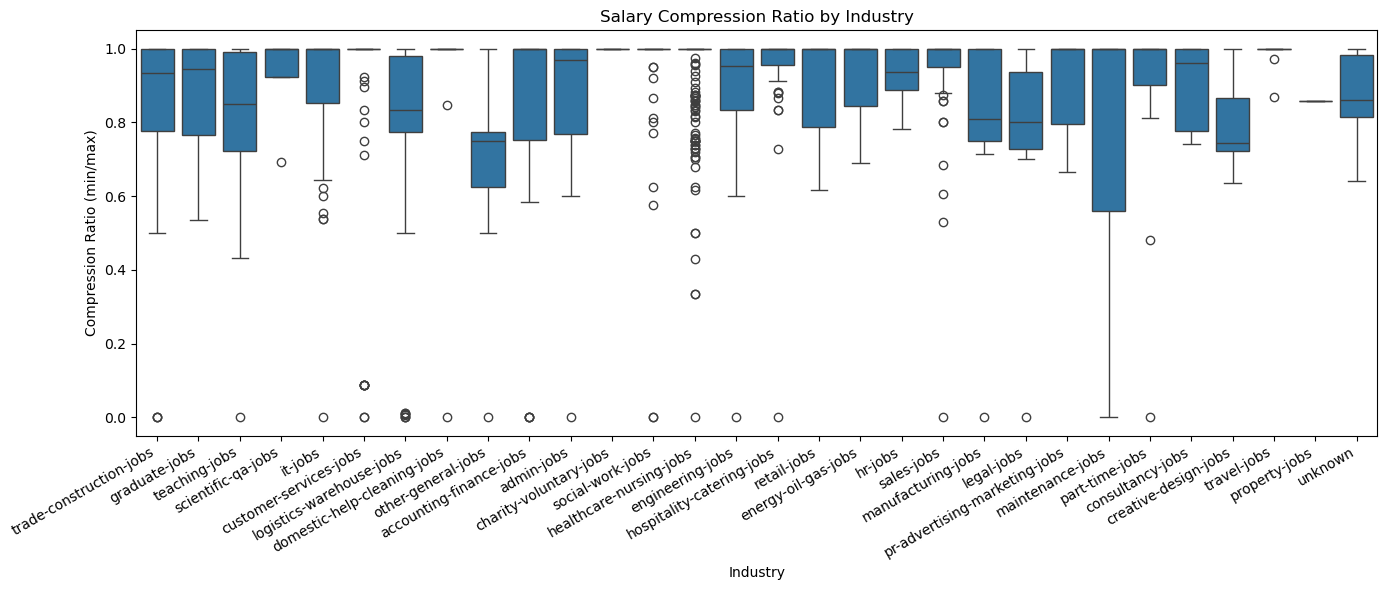


Average compression ratio by country:
 country
Netherlands       0.744214
Italy             0.748034
Switzerland       0.831197
United Kingdom    0.850660
Germany           0.852414
France            0.868397
Spain             0.906171
USA               0.968156
Name: compression_ratio, dtype: float64


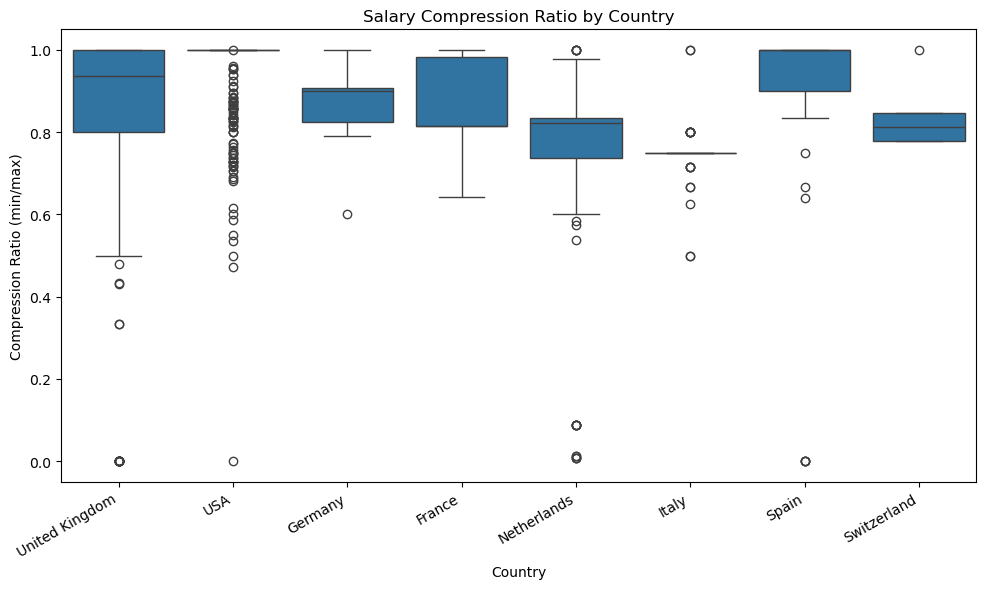

In [26]:

# compression ratio
df_filtered['compression_ratio'] = df_filtered['salary_min'] / df_filtered['salary_max']

# groupby industry
industry_compression = df_filtered.groupby('category_tag')['compression_ratio'].mean().sort_values()
print("Average compression ratio by industry:\n", industry_compression)

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_filtered, x='category_tag', y='compression_ratio')
plt.xticks(rotation=30, ha='right')
plt.title('Salary Compression Ratio by Industry')
plt.xlabel('Industry')
plt.ylabel('Compression Ratio (min/max)')
plt.tight_layout()
plt.show()

# group by country
region_compression = df_filtered.groupby('country')['compression_ratio'].mean().sort_values()
print("\nAverage compression ratio by country:\n", region_compression)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_filtered, x='country', y='compression_ratio')
plt.xticks(rotation=30, ha='right')
plt.title('Salary Compression Ratio by Country')
plt.xlabel('Country')
plt.ylabel('Compression Ratio (min/max)')
plt.tight_layout()
plt.show()



Across industries, salary compression ratios reveal clear differences in how tightly pay ranges are defined. Fields such as general jobs, logistics, and legal roles show wider ranges, with minimum salaries averaging only 68 to 79 percent of maximums, suggesting more flexibility or negotiation in compensation. Most industries cluster around ratios of 80 to 93 percent, indicating moderately tight ranges where minimums are close to maximums. At the other extreme, categories like travel and charity jobs show virtually no spread, with ratios near 100 percent, meaning salaries are fixed or standardized. This pattern highlights that industries differ not only in pay levels but also in how much room they allow for variation within postings. 

Across countries, compression ratios also vary, reflecting regional differences in how employers advertise pay. The Netherlands and Italy show the widest ranges, with ratios around 74 to 75 percent, suggesting more flexible salary structures. Switzerland, the United Kingdom, and Germany fall in the mid range, with ratios around 83 to 85 percent, showing moderately tight bands. France and Spain trend higher, with Spain at 91 percent, while the United States stands out with a ratio of 97 percent, indicating that most postings list fixed or nearly fixed salaries. This suggests that European markets often allow more negotiation or variability, while the United States market emphasizes clarity and consistency in advertised pay. This could be skewed due to salaries where ranges are listed from 0 to a maximum salary. This could also be indicative of how the jobs of each category are distributed across countries. 

#### Answers
How does salary compression ratio (min/max) compare across industries?
Do certain categories or regions show tighter or wider ranges?

Salary compression ratios vary across industries, with fields like general jobs and logistics showing wider ranges while sectors such as travel and charity tend to have fixed or nearly fixed salaries. Across regions, countries like the Netherlands and Italy display more flexible ranges, whereas the USA and Spain show much tighter bands with salaries advertised as nearly fixed

### References

Royle, Orianna Rosa. “The September Surge: Now Is the Best Time to Find a New
          Job, According to the Experts.” Fortune.Com, Sept. 2023, p. N.PAG. EBSCOhost,
          research.ebsco.com/linkprocessor/plink?id=1b989329-32f7-3910-88d8-4869d3238d0b.

### AI use Disclaimer:
Copilot AI was often used for grammar, formatting, brainstorming, and plot generation. Actual analysis avenues, plot selection, and exploration is our own.